In [1]:
import pandas as pd

# Load only a sample to get the code working
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
print("Data loaded successfully!")

stock_df = pd.read_csv('../data/raw/AAPL.csv')

Data loaded successfully!


In [2]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\derese\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
# Assign a score to every headline
news_df['sentiment'] = news_df['headline'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

In [ ]:
# Save the progress so i don't lose the 5 minutes of work!
news_df.to_csv('../data/news_with_sentiment.csv', index=False)

In [4]:
# 1. Convert 'date' to datetime format
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True)

# 2. Normalize: Move weekends (Saturday=5, Sunday=6) to the next Monday
news_df['trading_day'] = news_df['date'].apply(
    lambda x: x + pd.Timedelta(days=(7 - x.weekday())) if x.weekday() >= 5 else x
)

# 3. Keep only the date part (no time) to match stock data
news_df['date_only'] = news_df['trading_day'].dt.date
print("Dates aligned to trading days!")

Dates aligned to trading days!


In [5]:
# 1. Convert stock dates
stock_df['Date'] = pd.to_datetime(stock_df['Date']).dt.date

# 2. Calculate Daily Returns (Percentage change in price)
stock_df['Daily_Return'] = stock_df['Close'].pct_change()

print("Stock returns calculated!")

Stock returns calculated!


The Pearson Correlation Coefficient is: 0.0384


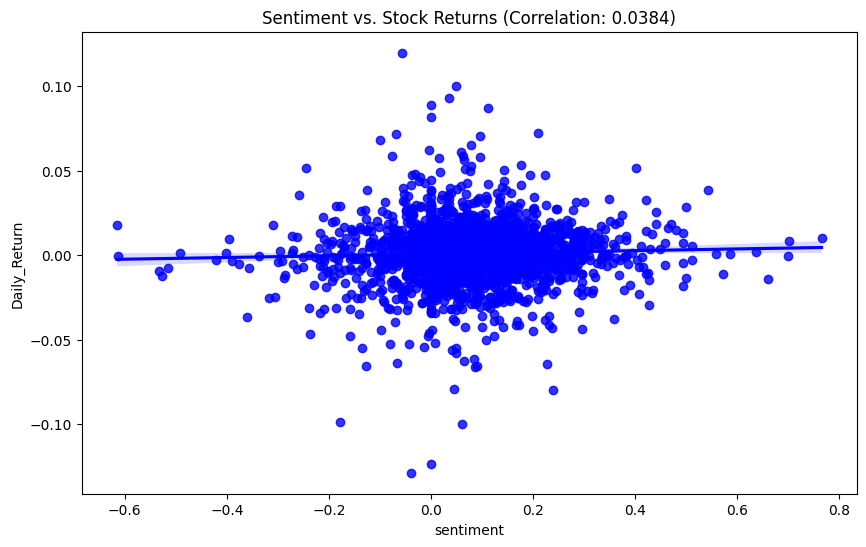

In [6]:
# 1. Group news by date and get the average sentiment for that day
daily_sentiment = news_df.groupby('date_only')['sentiment'].mean().reset_index()

# 2. Merge News with Stocks on the date
merged_df = pd.merge(daily_sentiment, stock_df[['Date', 'Daily_Return']], 
                     left_on='date_only', right_on='Date')

# 3. Calculate and Print Correlation
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return'])
print(f"The Pearson Correlation Coefficient is: {correlation:.4f}")

# 4. Final Visual (Scatter Plot)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(data=merged_df, x='sentiment', y='Daily_Return', color='blue')
plt.title(f'Sentiment vs. Stock Returns (Correlation: {correlation:.4f})')
plt.show()

Correlation Value: 0.0384.

Interpretation: There is a very weak positive correlation. This suggests that while positive news headlines have a slight tendency to align with positive stock returns, the market is likely driven more by the technical indicators you analyzed in Task 2.

Business Action: For Nova Financial Solutions, this means sentiment analysis should be used as a secondary signal alongside technical price data, rather than a primary decision-maker